In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    classification_report,
    confusion_matrix
)

# Load Titanic Dataset

In [2]:
df = pd.read_csv(
    "Titanic-Dataset.csv"
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

df["Embarked"] = (
    df["Embarked"]
    .fillna(
        df["Embarked"].mode()[0]
    )
)

df = df.drop(
    columns=["Cabin"]
)

# Task 1 - Linear Regression

In [4]:
features = [
    "Age",
    "SibSp",
    "Parch",
    "Pclass"
]

X = df[features]

y = df["Fare"]

In [5]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [6]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
predictions = lr.predict(
    X_test
)

predictions[:5]

array([17.90413163, 37.06937345,  2.68578224, 51.95920148,  8.83779702])

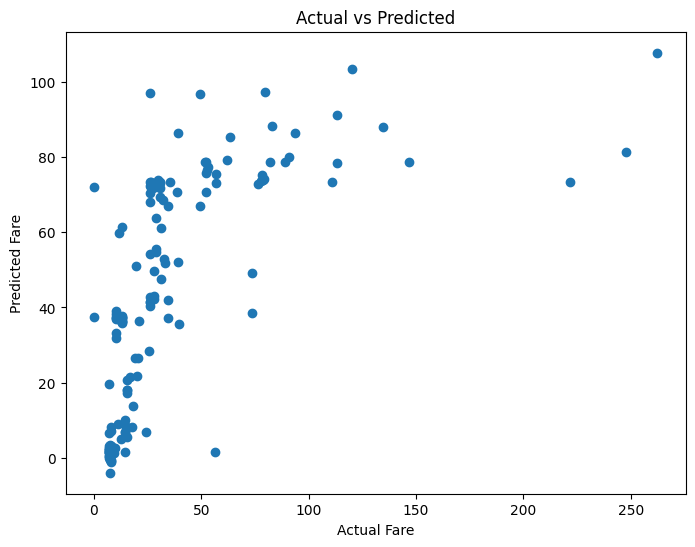

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Fare")

plt.ylabel("Predicted Fare")

plt.title(
    "Actual vs Predicted"
)

plt.show()

# Task 2 - Regression Metrics

In [9]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

print("MAE:", mae)

print("MSE:", mse)

print("RMSE:", rmse)

MAE: 19.781969090439052
MSE: 946.3355043476646
RMSE: 30.76256660858558


Interpretation:

MAE shows the average prediction error.

MSE penalizes larger errors more heavily.

RMSE is the square root of MSE and is measured in the same units as the target variable.

# Task 3 - Logistic Regression

In [10]:
data = df.copy()

encoder = LabelEncoder()

data["Sex"] = encoder.fit_transform(
    data["Sex"]
)

data["Embarked"] = encoder.fit_transform(
    data["Embarked"]
)

In [11]:
features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Sex",
    "Embarked"
]

X = data[features]

y = data["Survived"]

In [12]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [14]:
log_model = LogisticRegression()

log_model.fit(
    X_train,
    y_train
)

log_preds = log_model.predict(
    X_test
)

# Task 4 - Naive Bayes

In [15]:
nb_model = GaussianNB()

nb_model.fit(
    X_train,
    y_train
)

nb_preds = nb_model.predict(
    X_test
)

# Task 5 - KNN

In [16]:
for k in [3,5,7]:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        X_train,
        y_train
    )

    preds = knn.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        preds
    )

    print(
        f"k={k} Accuracy={accuracy:.4f}"
    )

k=3 Accuracy=0.7821
k=5 Accuracy=0.8045
k=7 Accuracy=0.8101


In [17]:
best_knn = KNeighborsClassifier(
    n_neighbors=5
)

best_knn.fit(
    X_train,
    y_train
)

knn_preds = (
    best_knn.predict(
        X_test
    )
)

# Task 6 - Evaluation Metrics

In [18]:
def evaluate_model(
    y_true,
    y_pred,
    model_name
):

    print("\n")
    print(model_name)

    print(
        "Accuracy:",
        accuracy_score(
            y_true,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred
        )
    )

    print(
        "F1:",
        f1_score(
            y_true,
            y_pred
        )
    )

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )

In [19]:
evaluate_model(
    y_test,
    log_preds,
    "Logistic Regression"
)

evaluate_model(
    y_test,
    nb_preds,
    "Naive Bayes"
)

evaluate_model(
    y_test,
    knn_preds,
    "KNN"
)



Logistic Regression
Accuracy: 0.8044692737430168
Precision: 0.782608695652174
Recall: 0.7297297297297297
F1: 0.7552447552447552
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

[[90 15]
 [20 54]]


Naive Bayes
Accuracy: 0.776536312849162
Precision: 0.7125
Recall: 0.7702702702702703
F1: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       105
           1       0.71      0.77      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179

[[82 23]
 [17 57]]


KNN
Accuracy: 0.8044692737430168
Precision: 0.782608695652174
Reca

# Task 7 - Overfitting and Underfitting

In [20]:
simple_model = LogisticRegression()

simple_model.fit(
    X_train,
    y_train
)

print(
    "Train Accuracy:",
    simple_model.score(
        X_train,
        y_train
    )
)

print(
    "Test Accuracy:",
    simple_model.score(
        X_test,
        y_test
    )
)

Train Accuracy: 0.800561797752809
Test Accuracy: 0.8044692737430168


In [21]:
complex_model = KNeighborsClassifier(
    n_neighbors=1
)

complex_model.fit(
    X_train,
    y_train
)

print(
    "Train Accuracy:",
    complex_model.score(
        X_train,
        y_train
    )
)

print(
    "Test Accuracy:",
    complex_model.score(
        X_test,
        y_test
    )
)

Train Accuracy: 0.9789325842696629
Test Accuracy: 0.7877094972067039


Observation:

The simple model may underfit because it has limited flexibility.

The KNN model with k=1 may overfit because it memorizes training examples.

A large gap between training accuracy and testing accuracy is often a sign of overfitting.

# Task 8 - Bias Variance Concept

1. What is Bias?

Bias is the error caused by overly simple assumptions in a model.

2. What is Variance?

Variance measures how sensitive a model is to changes in training data.

3. How do Bias and Variance relate to Underfitting and Overfitting?

High bias often leads to underfitting.
High variance often leads to overfitting.

4. How can we reduce Overfitting?

- Use more training data
- Reduce model complexity
- Apply regularization
- Use cross-validation